# Lesson 193 · Open FM reproduction — full task set

<div class="eyebrow">YEAR 5 · LESSON 193 · REPRODUCTION PRACTICE</div>

**One skill:** report a multi-task experiment without letting missing runs, incompatible units or selection decisions disappear inside an average. Read the core in about 15 minutes; do the notebook separately.

<div class="repro-status"><strong>Full model reproduction: INCOMPLETE.</strong> Fresh source diagnostic and complete ledger audit are finished. Model inference: NOT_RUN, 0/21 tasks. Cloud/API spend: $0. Learner: PENDING_WRITTEN_DEFENSE.</div>

## 1 · From one task to a task set

Our mission is to test whether relational structure adds value. A good result on one convenient task cannot carry that claim across databases. [Lesson 192's setup work](https://avistian.github.io/relational/lessons/0192-open-fm-setup-data.html) chose RDBLearn and inspected one task. Here we keep the same paper and released pipeline, but expand the **contract** to every reported task. L192 completed its setup audit, while model inference remained blocked. Its single-task protocol and saved preprocessing audit motivated the [fresh L193 check](https://avistian.github.io/relational/labs/evidence/l193/packet/preprocessing.json) that forms the bridge here.





[Lesson 178](https://avistian.github.io/relational/lessons/0178-fair-model-comparison.html) introduced this relational-features-plus-tabular-model approach. [Lesson 190](https://avistian.github.io/relational/lessons/0190-research-gap-checkpoint.html) separated evidence from a research claim. Today's new difficulty is accounting: the denominator is part of the experiment.

## 2 · Model architecture: where the shared risk lives

RDBLearn turns related rows into a fixed-width table, then supplies examples and queries to a pretrained tabular predictor. The relational feature generator has no learned encoder weights. The backend weights stay frozen during in-context prediction; fitting support/preprocessing is still data-dependent. Depth and backend are selected on validation. See the [primary paper, §§3–5](https://arxiv.org/html/2602.18495v1#S3).

<figure class="repro-figure">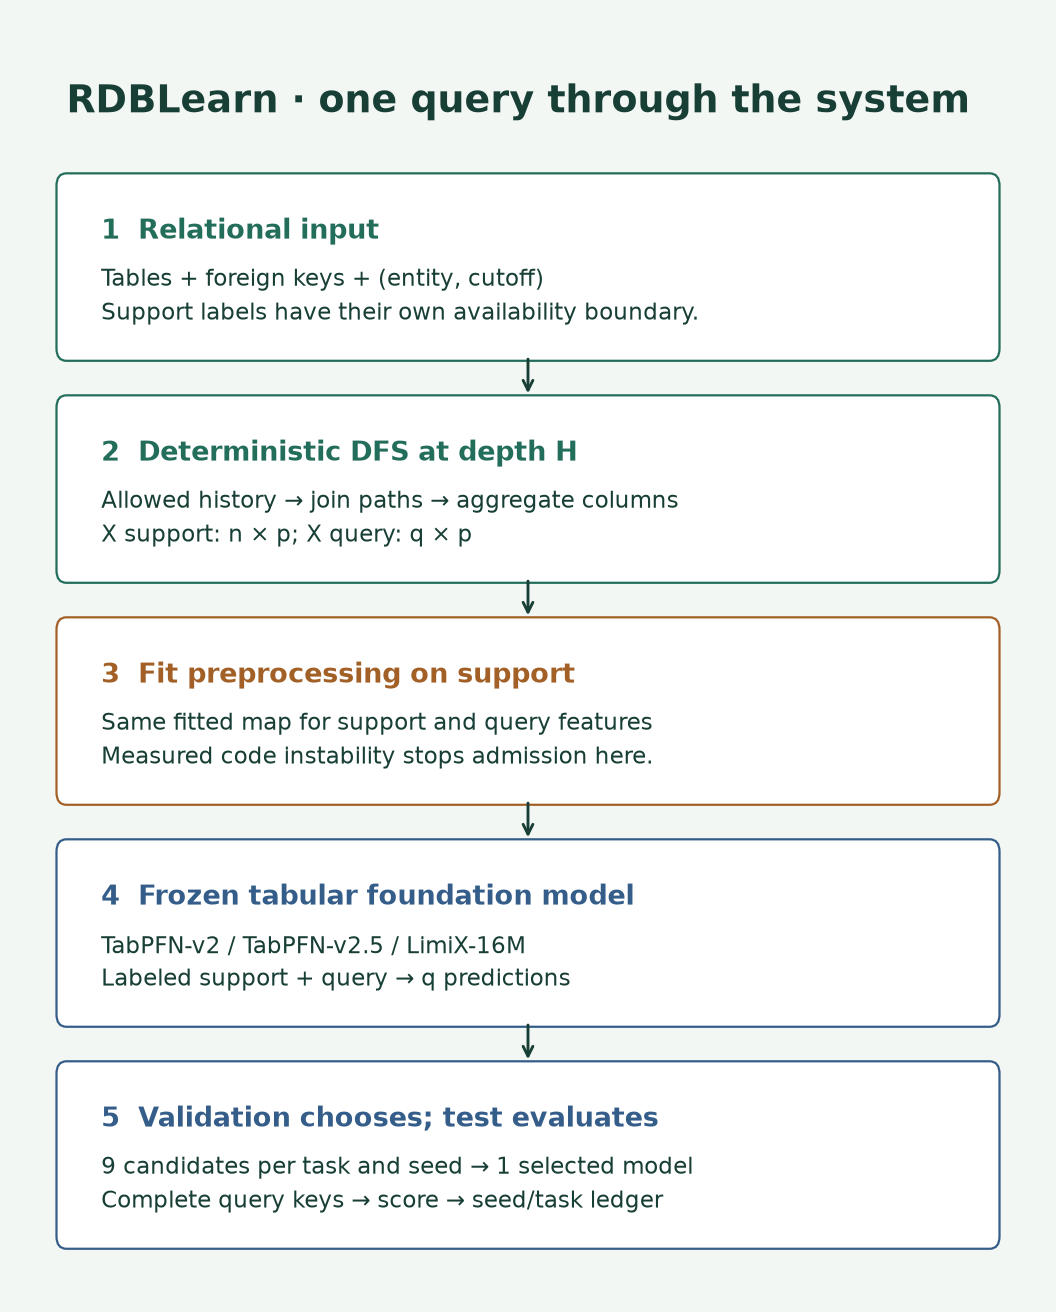<figcaption>RDBLearn computation and admission boundaries. Intended per-query temporal filtering requires its own audit. The shared preprocessing gate stopped the declared experiment before backend inference.</figcaption></figure>

Read one path: a query is `(entity, cutoff)` → restrict reachable rows to the allowed history → aggregate along join paths → produce one feature vector → apply the fitted preprocessing map → predict using labeled support. Support labels must also be available by the relevant prediction time. This is the intended contract; the drawing does not certify the released pipeline's temporal validity.

**Predict:** if preprocessing changes a fitted category's code after seeing a new query category, can every task safely reuse that pipeline?

We freshly ran the original full preprocessor on synthetic inputs. Fitting categories `b,c,d` gives codes `0,1,2`. Introducing `a` produces a sorted class list `a,b,c,d`, so the same known categories become `1,2,3`. The frozen support matrix still contains the earlier codes. The same query `b` is encoded differently alone and beside `a`.

<figure class="repro-figure">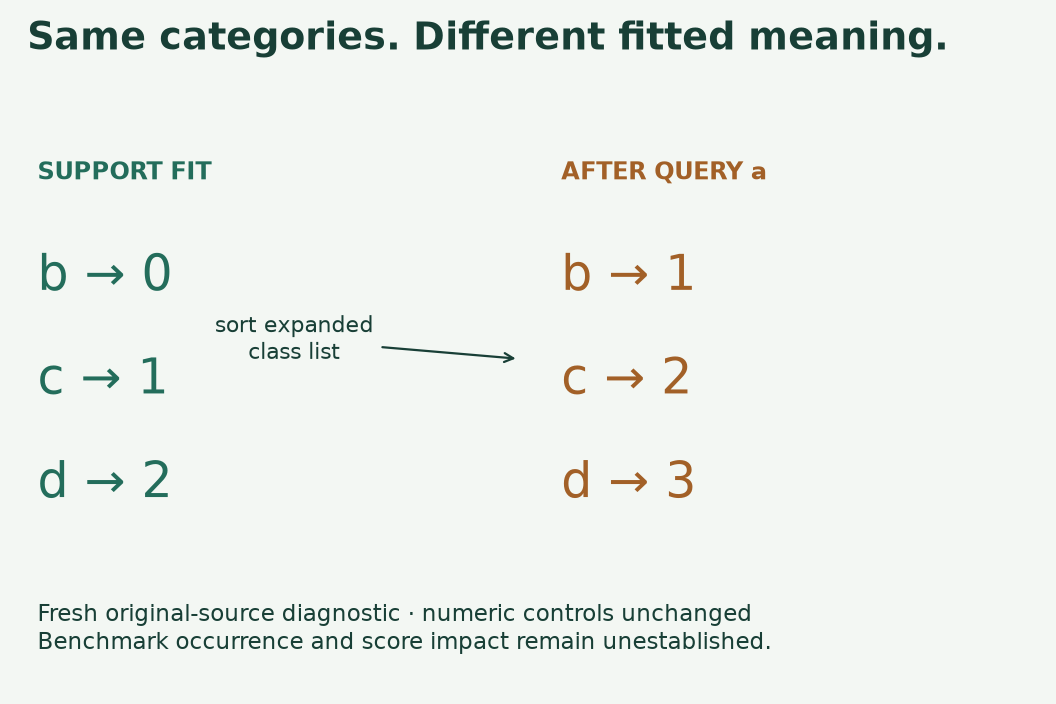<figcaption>Measured code changes for the same known categories after an unseen category is transformed. The diagram reports a synthetic source diagnostic, not task-level model accuracy.</figcaption></figure>


<p>Measured diagnostic: unseen a or 0 shifts all three known codes; unseen z or e shifts none. Numeric controls stay unchanged. Benchmark score impact is NOT_ESTABLISHED.</p>

This establishes a **source preprocessing invariant failure under the recorded environment**. It does not establish how often real tasks encounter the condition, how a backend reacts, or whether a paper score changes. We stop the declared suite at this shared admission check. Patching the encoder and claiming the original experiment would change the protocol. [Fresh observations](https://avistian.github.io/relational/labs/evidence/l193/packet/preprocessing.json) · [original-source diagnostic](https://avistian.github.io/relational/labs/_preflight_l193.py).

## 3 · Freeze the whole experiment before measuring

The chosen target is **RDBLearn, arXiv 2602.18495v1, Tables 1–3**: eight RelBench classification tasks, eight RelBench regression tasks and five 4DBInfer classification tasks. The full scope is the RDBLearn column; retraining every comparator or pretraining the tabular backends is outside it. [Paper §5 and Appendix A](https://arxiv.org/html/2602.18495v1#A1).

For each task and each course seed `0,1,2`, search depths `2,3,4` × backends `TabPFN-v2, TabPFN-v2.5, LimiX-16M`. Keep the published 10,000-example support cap and official splits. Three repeatability seeds are a disclosed extension: the original seeds are not recovered. Source release 0.1.2 and FastDFS 0.2.1 are pinned; checkpoint bytes, full data identities and the historical environment remain unestablished.

**Count it:** `21 × 3 × 9 = 567` validation candidates, then `21 × 3 = 63` selected test evaluations. A failed candidate is not permission to select among eight. A missing seed is not permission to report a two-seed result as three-seed reproduction.

```python
def choose_config(rows,order,metric):
    """Require the complete declared candidate set; use validation only, stable ties."""
    if metric not in ['AUROC','MAE'] or not order or len(set(order))!=len(order):
        raise ValueError('Invalid metric or candidate order')
    scores={}
    for row in rows:
        value=row['score']
        if row['split']!='val' or row['id'] in scores or not math.isfinite(value):
            raise ValueError('Duplicate, nonfinite or non-validation candidate')
        if value<0 or (metric=='AUROC' and value>1):raise ValueError('Invalid score')
        scores[row['id']]=value
    if set(scores)!=set(order):raise ValueError('Incomplete candidate set')
    direction=-1 if metric=='AUROC' else 1
    return min(order,key=lambda name:direction*scores[name])
```

The function refuses incomplete candidate sets and test-split scores. It breaks equal validation scores using the order frozen before execution. Classification maximizes AUROC; regression minimizes MAE. Fresh scoring would align complete query identities and independently recalculate metrics before admitting any `COMPLETE` row.

**Admission and budget:** $10 total, planned stop at $8 with $2 reserve, including preparation, retries and verification. The full-run forecast remains `NOT_ESTABLISHED`: the source gate failed before a model pilot. No paid run was launched. The [executable admission operator](https://avistian.github.io/relational/labs/_reproduce_l193.py) exits with a documented stop; its downstream GPU executor is **not implemented or validated**. The full [validation schedule](https://avistian.github.io/relational/labs/evidence/l193/validation-schedule.json) and [test schedule](https://avistian.github.io/relational/labs/evidence/l193/test-schedule.json) remain available for continuation.

## 4 · Two denominators before one mean

First summarize **within each task** over its complete seed set. Then summarize **across tasks** within a comparable metric group. These are different sources of variation. For synthetic seed scores `[0.60,0.70,0.80]`, the mean is `0.70` and sample SD is `0.10`, using denominator `3−1`. A missing third run leaves the full-seed mean blank. Seed SD is not uncertainty across databases.

<figure class="repro-figure">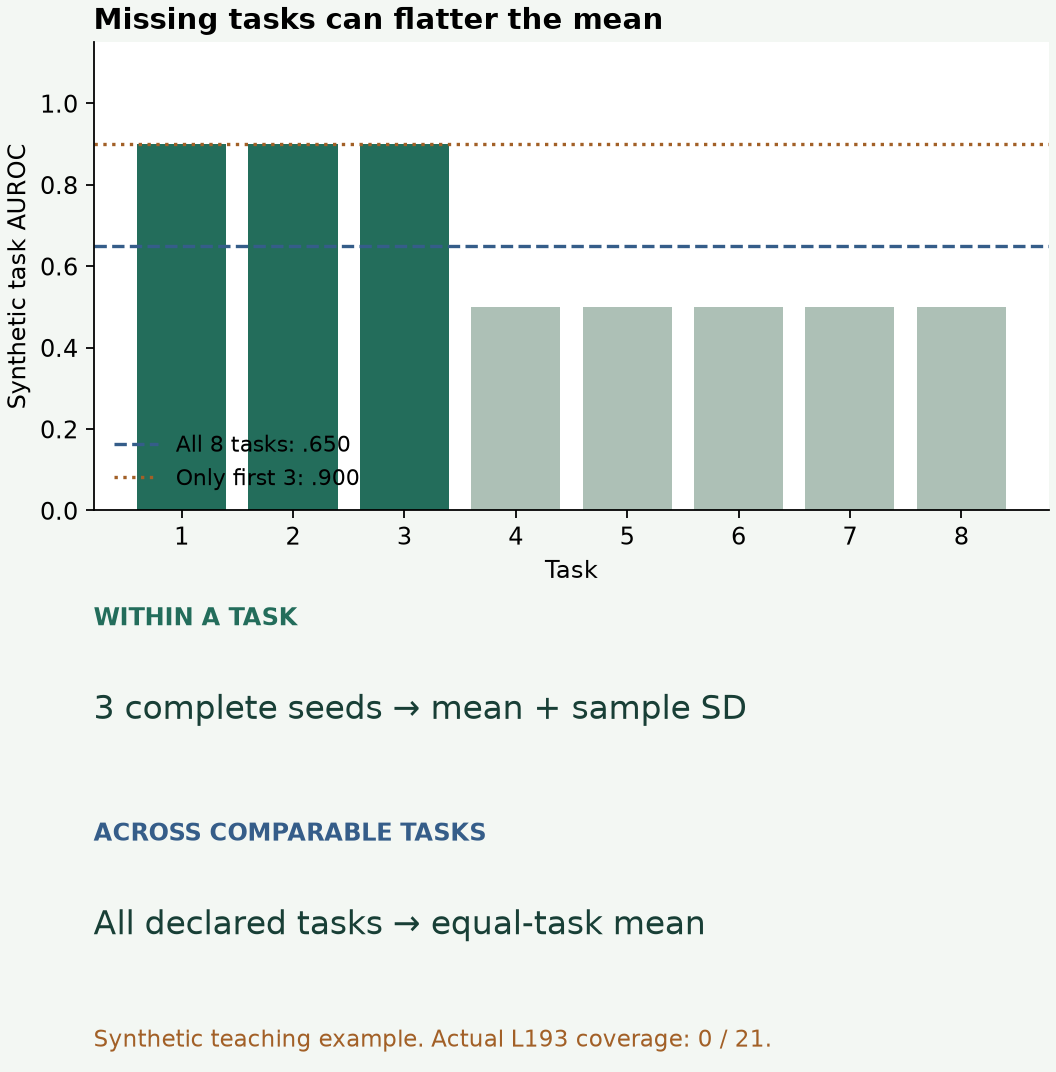<figcaption>Authored missingness example and the two levels of aggregation. Support-seed variation and variation across tasks answer different questions.</figcaption></figure>

The browser exercise below is synthetic. Its eight task scores are `[.9,.9,.9,.5,.5,.5,.5,.5]`. Each checked box stands for a task with all three seeds complete. Start with only the three easy tasks. The observed-subset mean is `.900`; restoring all eight gives `.650`. Dropping difficult tasks creates a more flattering answer to a different question.


<p>Synthetic example: three selected tasks average .900; all eight average .650. Until all eight are present, the full-suite mean is withheld. Actual L193 model coverage remains 0/21.</p>

**Equal task weighting:** average each task's seed mean once. Do not pool every prediction row; large tasks would dominate. Tasks within one database may also be dependent, so an across-task SD is descriptive rather than a database-transfer confidence interval.

**Expose the weighting decision.** Imagine two complete tasks with seed-mean AUROCs 0.90 and 0.50. The first has 100 test queries and the second 900:

<table class="compact-trace" style="min-width:0;border-collapse:separate;border-spacing:3px"><thead><tr><th>Summary</th><th>Calculation</th><th>Value</th></tr></thead><tbody><tr><td>Equal task weights</td><td>(0.90 + 0.50)/2</td><td>0.70</td></tr><tr><td>Query-count weights</td><td>(100 × 0.90 + 900 × 0.50)/1,000</td><td>0.54</td></tr><tr><td>Drop second task</td><td>Full-suite mean withheld</td><td>Incomplete</td></tr></tbody></table>

The first asks about a uniformly selected task; the second favors tasks with more queries. The second is a weighted mean of per-task AUROCs, **not** AUROC computed after pooling all predictions: pooled AUROC also compares positives and negatives across tasks and cannot be recovered from these two scalars. The frozen suite uses the first rule.

**Transfer the trace.** Duplicate the second task's query rows while holding its AUROC fixed. Equal-task mean stays 0.70; query-count-weighted mean becomes `(90 + 900)/1,900 ≈ 0.5211`. A bookkeeping change has altered the latter summary without improving or degrading either task's ranking.


**Units matter:** AUROC is dimensionless. Raw MAEs for money, counts and rates are not commensurate. Given verified baseline errors `b_t`, normalized MAE is `MAE_t / b_t`, then averaged across tasks. Example: errors `[5,.2]` and baseline errors `[10,.1]` yield normalized errors `[.5,2]`, mean `1.25`. The smaller raw error can be worse relative to its baseline.

The paper's §5 describes normalization using a no-relational-context baseline, but Table 2 labels its values MAE and does not supply an unambiguous normalization recipe and denominators. The AutoGluon-without-RDB column is not automatically that baseline. We retain raw per-task targets and leave aggregate regression parity **NOT_ESTABLISHED**. The lab rejects missing or nonpositive denominators rather than silently substituting a target standard deviation.


<p>Choose: “Keep every missing task visible.” This preserves the declared denominator. Averaging only successful tasks changes the population.</p>

## 5 · The full results table, including absence

| Task | Metric | Paper target | Fresh mean ± SD | Coverage |
|---|---|---:|---|---|
| relbench/rel-amazon/item-churn | AUROC | 0.8188 | — NOT_RUN | 0/3 seeds |
| relbench/rel-amazon/user-churn | AUROC | 0.6823 | — NOT_RUN | 0/3 seeds |
| relbench/rel-avito/user-clicks | AUROC | 0.6709 | — NOT_RUN | 0/3 seeds |
| relbench/rel-avito/user-visits | AUROC | 0.6569 | — NOT_RUN | 0/3 seeds |
| relbench/rel-hm/user-churn | AUROC | 0.6802 | — NOT_RUN | 0/3 seeds |
| relbench/rel-stack/user-badge | AUROC | 0.8430 | — NOT_RUN | 0/3 seeds |
| relbench/rel-stack/user-engagement | AUROC | 0.8935 | — NOT_RUN | 0/3 seeds |
| relbench/rel-trial/study-outcome | AUROC | 0.7167 | — NOT_RUN | 0/3 seeds |
| relbench/rel-amazon/item-ltv | MAE | 48.5044 | — NOT_RUN | 0/3 seeds |
| relbench/rel-amazon/user-ltv | MAE | 14.5290 | — NOT_RUN | 0/3 seeds |
| relbench/rel-avito/ad-ctr | MAE | 0.0341 | — NOT_RUN | 0/3 seeds |
| relbench/rel-event/user-attendance | MAE | 0.2393 | — NOT_RUN | 0/3 seeds |
| relbench/rel-hm/item-sales | MAE | 0.0630 | — NOT_RUN | 0/3 seeds |
| relbench/rel-stack/post-votes | MAE | 0.0676 | — NOT_RUN | 0/3 seeds |
| relbench/rel-trial/site-success | MAE | 0.4179 | — NOT_RUN | 0/3 seeds |
| relbench/rel-trial/study-adverse | MAE | 44.5186 | — NOT_RUN | 0/3 seeds |
| 4dbinfer/amazon/churn | AUROC | 0.7777 | — NOT_RUN | 0/3 seeds |
| 4dbinfer/outbrain/ctr-100k | AUROC | 0.5499 | — NOT_RUN | 0/3 seeds |
| 4dbinfer/retailrocket/cvr | AUROC | 0.8609 | — NOT_RUN | 0/3 seeds |
| 4dbinfer/stackexchange/post-upvote | AUROC | 0.8736 | — NOT_RUN | 0/3 seeds |
| 4dbinfer/stackexchange/user-churn | AUROC | 0.8774 | — NOT_RUN | 0/3 seeds |

Every row retains the published target beside a blank fresh result. The paper numbers are reference scalars; they are not saved predictions or fresh measurements. For compactness, the table shows one task row; the [run ledger](https://avistian.github.io/relational/labs/evidence/l193/packet/runs.json) retains all 63 seed slots and reasons. Every row has the same suite-level stop reason, not an asserted task-specific defect.

Arithmetic on the rounded published classification values gives **0.7452875** over the eight RelBench tasks and **0.7879000** over the five 4DBInfer tasks. We independently parsed and checked all 21 table entries. Those two means reproduce a calculation on printed numbers, not the experiments that generated them; seed variance cannot be recovered from these single scalars.

Actual fresh model evaluations: **0 / 630**. Actual completed task results: **0 / 21**. The diagnostic is complete; full model reproduction is **INCOMPLETE_SOURCE_PREPROCESSING_GATE**. [Report](https://avistian.github.io/relational/labs/evidence/l193/report.json) · [independent verification](https://avistian.github.io/relational/labs/_verify_l193_results.json).

## 6 · Implement, challenge, defend

[Student notebook](https://avistian.github.io/relational/labs/0193-open-fm-full-task-set.ipynb) · [executed solution](https://avistian.github.io/relational/labs/solutions/0193-open-fm-full-task-set.ipynb) · [readable lab](https://avistian.github.io/relational/labs/html/0193-open-fm-full-task-set.html) · [field guide](https://avistian.github.io/relational/reference/open-fm-full-task-set.html).

Implement three live contracts: `choose_config`, `summarize_task`, `aggregate_suite`. Each feeds the checks or complete packet report. Reject a test-split candidate; mark one seed missing; try averaging two regression tasks without their denominators. The portable replay authenticates evidence and recomputes the report without downloading models. It replays recorded diagnostic observations; the original-source diagnostic is a separate environment-dependent command.

**EXIT:** write a paragraph containing (1) the named 21-task target, (2) the strongest completed evidence, (3) the precise reason model inference stopped, (4) the denominator and uncertainty you would report after a valid complete run, and (5) what must be established before continuation. Explain why fixing the encoder creates a new experimental variant. [Lesson 194](https://avistian.github.io/relational/lessons/0194-open-fm-analysis-report.html) turns this ledger into a per-task analysis and report; blank scores cannot support win/loss attribution.

Ask the tutor about any unclear step, or submit your implementation and defense for review. This prepared package does not establish learner mastery: **PENDING_WRITTEN_DEFENSE**.


<!-- course-portable:start -->
### Follow the computation

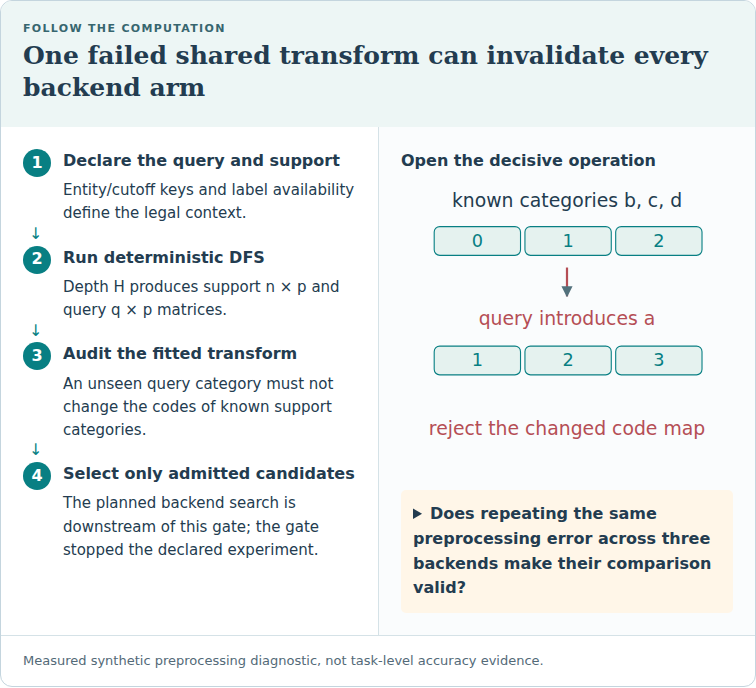

Measured synthetic preprocessing diagnostic, not task-level accuracy evidence.

**Trace question:** Does repeating the same preprocessing error across three backends make their comparison valid?

**Trace answer:** No. Shared code is not proof of correct input semantics. All dependent arms inherit the failed admission gate.
<!-- course-portable:end -->

## PROVIDED · Offline audit packet
Python3 standard library only. The entire frozen task ledger, paper reference and original-source diagnostic observations are embedded. This notebook audits the packet; it does not execute the upstream preprocessor or run GPU models. No repository checkout, account, downloads or installation required.

In [ ]:
import base64, hashlib, io, json, math, statistics, tempfile, zipfile
from pathlib import Path
workspace=Path(tempfile.mkdtemp(prefix="l193-audit-"))

In [ ]:
payload='...'
raw=base64.b64decode(payload)
assert hashlib.sha256(raw).hexdigest()=='839653d4d11e98d9bf66ea9bc4ef994556e39a99e30c737e61e3fdc5ce0b5a03'
with zipfile.ZipFile(io.BytesIO(raw)) as archive:
    for name in archive.namelist():
        if not (workspace/name).resolve().is_relative_to(workspace.resolve()):
            raise ValueError("Unsafe archive path")
    archive.extractall(workspace)
packet=workspace/"packet"
manifest=json.loads((workspace/"input-manifest.json").read_text())
tasks=json.loads((packet/"tasks.json").read_text())

## TODO · choose_config
Require all unique candidate IDs from order. Every split must be val; scores finite and in the metric domain. Maximize AUROC, minimize MAE; ties use order.

Predict a failure case before writing code. The exact reference contract is visible in the executed solution; try your own first.

In [ ]:
def choose_config(rows,order,metric):
    # TODO: implement the contract above.
    raise NotImplementedError('choose_config')

### CHECK · Synthetic contract examples

In [ ]:
rows=[dict(id='b',split='val',score=.7),dict(id='a',split='val',score=.7)]
assert choose_config(rows,['a','b'],'AUROC')=='a'
try:
    choose_config([dict(rows[0],split='test'),rows[1]],['a','b'],'AUROC')
except ValueError:
    pass
else:
    raise AssertionError('Test contamination accepted')
print("Contract check PASS")

## TODO · summarize_task
Require exact task/seed identities. COMPLETE rows have finite scores; NOT_RUN/FAILED rows have null scores. Return task, status, expected_seeds, completed_seeds, mean, sample_sd. Mean/SD stay null unless all seeds complete (single-seed SD is null).

Predict a failure case before writing code. The exact reference contract is visible in the executed solution; try your own first.

In [ ]:
def summarize_task(task,runs,seeds):
    # TODO: implement the contract above.
    raise NotImplementedError('summarize_task')

### CHECK · Synthetic contract examples

In [ ]:
toy_task=dict(id='toy',metric='AUROC',group='classification',normalizer=None)
toy_runs=[dict(task='toy',seed=s,status='COMPLETE',score=v) for s,v in enumerate([.6,.7,.8])]
summary=summarize_task(toy_task,toy_runs,[0,1,2])
assert abs(summary['mean']-.7)<1e-12 and abs(summary['sample_sd']-.1)<1e-12
toy_runs[2].update(status='NOT_RUN',score=None)
assert summarize_task(toy_task,toy_runs,[0,1,2])['mean'] is None
print("Contract check PASS")

## TODO · aggregate_suite
Require exactly one summary per declared task. Group by benchmark/metric; equal task weights. Return status, expected_tasks, complete_tasks, metric, mean per group. Only complete groups get a mean; MAE requires positive task normalizer values and reports NORMALIZED_MAE. Unknown normalizers yield NORMALIZER_NOT_ESTABLISHED.

Predict a failure case before writing code. The exact reference contract is visible in the executed solution; try your own first.

In [ ]:
def aggregate_suite(tasks,summaries):
    # TODO: implement the contract above.
    raise NotImplementedError('aggregate_suite')

### CHECK · Synthetic contract examples

In [ ]:
toy_tasks=[dict(id='a',metric='MAE',group='regression',normalizer=10),dict(id='b',metric='MAE',group='regression',normalizer=.1)]
toy_summaries=[dict(task='a',status='COMPLETE',mean=5),dict(task='b',status='COMPLETE',mean=.2)]
assert aggregate_suite(toy_tasks,toy_summaries)['regression']['mean']==1.25
toy_tasks[1]['normalizer']=None
assert aggregate_suite(toy_tasks,toy_summaries)['regression']['mean'] is None
print("Contract check PASS")

## PROVIDED · Full authenticated replay
This operator calls all three learner functions. Paper scalars and synthetic exercises are clearly separated from the empty fresh-model ledger. Read the completeness and source checks before executing.

In [ ]:
def replay193(packet,manifest,choose_config,summarize_task,aggregate_suite):
    packet=Path(packet)
    expected=set(manifest['files']);actual={p.name for p in packet.iterdir() if p.is_file()}
    if expected!=actual:raise ValueError('Packet membership mismatch')
    for name,digest in manifest['files'].items():
        if Path(name).name!=name or hashlib.sha256((packet/name).read_bytes()).hexdigest()!=digest:raise ValueError('Corrupt input: '+name)
    tasks=json.loads((packet/'tasks.json').read_text());protocol=json.loads((packet/'protocol.json').read_text());runs=json.loads((packet/'runs.json').read_text());probe=json.loads((packet/'preprocessing.json').read_text())
    candidates=[f'd{d}-{b}' for d in protocol['depths'] for b in protocol['backends']]
    schedule=json.loads((packet/'validation-schedule.json').read_text());tests=json.loads((packet/'test-schedule.json').read_text())
    wanted={(t['id'],s,c) for t in tasks for s in protocol['seeds'] for c in candidates}
    got=[(r['task'],r['seed'],r['candidate']) for r in schedule]
    if len(got)!=len(set(got)) or set(got)!=wanted or any(r['status']!='NOT_RUN' or r['phase']!='validation' for r in schedule):raise ValueError('Incomplete validation schedule')
    expected_tests={(t['id'],s) for t in tasks for s in protocol['seeds']}
    if len(tests)!=len(expected_tests) or {(r['task'],r['seed']) for r in tests}!=expected_tests or any(r['status']!='NOT_RUN' or r['selected_candidate'] is not None for r in tests):raise ValueError('Invalid test schedule')
    if len(runs)!=len(expected_tests) or {(r['task'],r['seed']) for r in runs}!=expected_tests:raise ValueError('Incomplete run ledger')
    changed=[]
    before_map={c:i for i,c in enumerate(sorted(probe['train_categories']))}
    for obs in probe['observations']:
        after_map={c:i for i,c in enumerate(sorted(probe['train_categories']+[obs['unseen']]))}
        old=[before_map[c] for c in probe['known_categories']];new=[after_map[c] for c in probe['known_categories']]
        count=sum(a!=b for a,b in zip(old,new))
        if obs['before']!=old or obs['after']!=new or obs['changed_codes']!=count or obs['numeric_before']!=obs['numeric_after']:raise ValueError('Diagnostic arithmetic mismatch')
        if obs['query_alone']!=[before_map['b']] or obs['query_with_other']!=[after_map[obs['unseen']],after_map['b']]:raise ValueError('Query batch control mismatch')
        changed.append(count)
    if not any(changed) or probe['status']!='FAIL':raise ValueError('Expected recorded source gate failure')
    if hashlib.sha256((packet/'preprocessing.py').read_bytes()).hexdigest()!=probe['source_sha256']:raise ValueError('Wrong diagnostic source')
    if any(r['status']!='NOT_RUN' or r['score'] is not None for r in runs):raise ValueError('Model result fabricated after failed gate')
    summaries=[summarize_task(t,[r for r in runs if r['task']==t['id']],protocol['seeds']) for t in tasks]
    aggregates=aggregate_suite(tasks,summaries)
    reference={g:dict(tasks=sum(t['group']==g for t in tasks),mean_auc=statistics.mean(t['paper_score'] for t in tasks if t['group']==g),scope='Arithmetic on rounded published scalars, not a model replay') for g in ['relbench_classification','4dbinfer_classification']}
    # This is a labeled exercise, not nine observed model outputs.
    toy=[dict(id=c,split='val',score=.60+i*.01) for i,c in enumerate(candidates)]
    winner=choose_config(toy,candidates,'AUROC')
    return dict(status='INCOMPLETE_SOURCE_PREPROCESSING_GATE',task_count=len(tasks),validation_slots=len(schedule),test_slots=len(tests),executed_model_evaluations=0,task_results=summaries,groups=aggregates,published_reference=reference,regression_normalization='NOT_ESTABLISHED',diagnostic=dict(cases=len(changed),changed_known_codes=changed,numeric_controls='UNCHANGED',source='FRESH_ORIGINAL_PREPROCESSOR',task_effect='NOT_ESTABLISHED'),selection_exercise=dict(scope='SYNTHETIC',winner=winner),fresh_inference='NOT_RUN',pretraining='NOT_RUN',whole_paper='NOT_RUN',historical_identity='NOT_ESTABLISHED',forecast='NOT_ESTABLISHED',cloud_usd=0,learner='PENDING_WRITTEN_DEFENSE')

## CHECK · Every task and every planned run
Compare the complete report, not a selected scalar.

In [ ]:
report=replay193(packet,manifest,choose_config,summarize_task,aggregate_suite)
assert report==json.loads('{"cloud_usd": 0, "diagnostic": {"cases": 4, "changed_known_codes": [3, 0, 3, 0], "numeric_controls": "UNCHANGED", "source": "FRESH_ORIGINAL_PREPROCESSOR", "task_effect": "NOT_ESTABLISHED"}, "executed_model_evaluations": 0, "forecast": "NOT_ESTABLISHED", "fresh_inference": "NOT_RUN", "groups": {"4dbinfer_classification": {"complete_tasks": 0, "expected_tasks": 5, "mean": null, "metric": "AUROC", "status": "INCOMPLETE"}, "relbench_classification": {"complete_tasks": 0, "expected_tasks": 8, "mean": null, "metric": "AUROC", "status": "INCOMPLETE"}, "relbench_regression": {"complete_tasks": 0, "expected_tasks": 8, "mean": null, "metric": "NORMALIZED_MAE", "status": "INCOMPLETE"}}, "historical_identity": "NOT_ESTABLISHED", "learner": "PENDING_WRITTEN_DEFENSE", "pretraining": "NOT_RUN", "published_reference": {"4dbinfer_classification": {"mean_auc": 0.7879, "scope": "Arithmetic on rounded published scalars, not a model replay", "tasks": 5}, "relbench_classification": {"mean_auc": 0.7452875, "scope": "Arithmetic on rounded published scalars, not a model replay", "tasks": 8}}, "regression_normalization": "NOT_ESTABLISHED", "selection_exercise": {"scope": "SYNTHETIC", "winner": "d4-LimiX-16M"}, "status": "INCOMPLETE_SOURCE_PREPROCESSING_GATE", "task_count": 21, "task_results": [{"completed_seeds": 0, "expected_seeds": 3, "mean": null, "sample_sd": null, "status": "INCOMPLETE", "task": "relbench/rel-amazon/item-churn"}, {"completed_seeds": 0, "expected_seeds": 3, "mean": null, "sample_sd": null, "status": "INCOMPLETE", "task": "relbench/rel-amazon/user-churn"}, {"completed_seeds": 0, "expected_seeds": 3, "mean": null, "sample_sd": null, "status": "INCOMPLETE", "task": "relbench/rel-avito/user-clicks"}, {"completed_seeds": 0, "expected_seeds": 3, "mean": null, "sample_sd": null, "status": "INCOMPLETE", "task": "relbench/rel-avito/user-visits"}, {"completed_seeds": 0, "expected_seeds": 3, "mean": null, "sample_sd": null, "status": "INCOMPLETE", "task": "relbench/rel-hm/user-churn"}, {"completed_seeds": 0, "expected_seeds": 3, "mean": null, "sample_sd": null, "status": "INCOMPLETE", "task": "relbench/rel-stack/user-badge"}, {"completed_seeds": 0, "expected_seeds": 3, "mean": null, "sample_sd": null, "status": "INCOMPLETE", "task": "relbench/rel-stack/user-engagement"}, {"completed_seeds": 0, "expected_seeds": 3, "mean": null, "sample_sd": null, "status": "INCOMPLETE", "task": "relbench/rel-trial/study-outcome"}, {"completed_seeds": 0, "expected_seeds": 3, "mean": null, "sample_sd": null, "status": "INCOMPLETE", "task": "relbench/rel-amazon/item-ltv"}, {"completed_seeds": 0, "expected_seeds": 3, "mean": null, "sample_sd": null, "status": "INCOMPLETE", "task": "relbench/rel-amazon/user-ltv"}, {"completed_seeds": 0, "expected_seeds": 3, "mean": null, "sample_sd": null, "status": "INCOMPLETE", "task": "relbench/rel-avito/ad-ctr"}, {"completed_seeds": 0, "expected_seeds": 3, "mean": null, "sample_sd": null, "status": "INCOMPLETE", "task": "relbench/rel-event/user-attendance"}, {"completed_seeds": 0, "expected_seeds": 3, "mean": null, "sample_sd": null, "status": "INCOMPLETE", "task": "relbench/rel-hm/item-sales"}, {"completed_seeds": 0, "expected_seeds": 3, "mean": null, "sample_sd": null, "status": "INCOMPLETE", "task": "relbench/rel-stack/post-votes"}, {"completed_seeds": 0, "expected_seeds": 3, "mean": null, "sample_sd": null, "status": "INCOMPLETE", "task": "relbench/rel-trial/site-success"}, {"completed_seeds": 0, "expected_seeds": 3, "mean": null, "sample_sd": null, "status": "INCOMPLETE", "task": "relbench/rel-trial/study-adverse"}, {"completed_seeds": 0, "expected_seeds": 3, "mean": null, "sample_sd": null, "status": "INCOMPLETE", "task": "4dbinfer/amazon/churn"}, {"completed_seeds": 0, "expected_seeds": 3, "mean": null, "sample_sd": null, "status": "INCOMPLETE", "task": "4dbinfer/outbrain/ctr-100k"}, {"completed_seeds": 0, "expected_seeds": 3, "mean": null, "sample_sd": null, "status": "INCOMPLETE", "task": "4dbinfer/retailrocket/cvr"}, {"completed_seeds": 0, "expected_seeds": 3, "mean": null, "sample_sd": null, "status": "INCOMPLETE", "task": "4dbinfer/stackexchange/post-upvote"}, {"completed_seeds": 0, "expected_seeds": 3, "mean": null, "sample_sd": null, "status": "INCOMPLETE", "task": "4dbinfer/stackexchange/user-churn"}], "test_slots": 63, "validation_slots": 567, "whole_paper": "NOT_RUN"}')
Path("l193-report.json").write_text(json.dumps(report,indent=2))
print(report["status"])
print("Tasks:",report["task_count"],"| Validation slots:",report["validation_slots"],"| Test slots:",report["test_slots"])
print("Executed model evaluations:",report["executed_model_evaluations"])
print("Source diagnostic:",report["diagnostic"])
print("Published reference arithmetic:",report["published_reference"])

## EXIT · Defend a result table
Write the named experiment, completed evidence, exact stop reason, aggregation denominator, uncertainty interpretation and prerequisites for resuming. Explain why a repaired pipeline is a separate variant. Ask the tutor to review your answer; author checks cannot complete your exit.

In [ ]:
submission=dict(learner="PENDING_WRITTEN_DEFENSE",named_experiment="",evidence="",stop_reason="",denominator="",uncertainty="",continuation="",repair_boundary="")
Path("l193-submission.json").write_text(json.dumps(submission,indent=2))